In [13]:
# =============================================================================
# Шаг 0: Настройка окружения и загрузка данных
# =============================================================================

# 1. Импорт всех необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Модели
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression # Для стекинга

# Метрики и утилиты
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

# Настройки для визуализации
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# 2. Загрузка обработанных данных
df = pd.read_csv('../data/02_processed/churn_data_processed.csv')

print("Обработанный датасет успешно загружен.")
print("Размерность:", df.shape)
display(df.head())

# 3. Разделение на признаки (X) и целевую переменную (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

print(f"Размерность X (признаки): {X.shape}")
print(f"Размерность y (цель): {y.shape}")

Обработанный датасет успешно загружен.
Размерность: (7032, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.280248,0,1,-1.161694,-0.994194,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,0.064303,1,0,-0.260878,-0.173740,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,-1.239504,1,1,-0.363923,-0.959649,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,0.512486,0,0,-0.747850,-0.195248,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,-1.239504,1,1,0.196178,-0.940457,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


Размерность X (признаки): (7032, 30)
Размерность y (цель): (7032,)


In [14]:
# =============================================================================
# Шаг 1: Разделение данных на обучающую и тестовую выборки
# =============================================================================

# Используем train_test_split для разделения данных
# test_size=0.2 означает, что 20% данных пойдет в тестовую выборку
# random_state=42 для воспроизводимости результатов
# stratify=y гарантирует, что пропорция классов (0 и 1) будет одинаковой в train и test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nДанные успешно разделены на обучающую и тестовую выборки:")
print(f"Размер X_train: {X_train.shape}")
print(f"Размер X_test: {X_test.shape}")
print(f"\nПроцент 'Churn' в y_train: {y_train.mean():.2%}")
print(f"Процент 'Churn' в y_test:  {y_test.mean():.2%}")


Данные успешно разделены на обучающую и тестовую выборки:
Размер X_train: (5625, 30)
Размер X_test: (1407, 30)

Процент 'Churn' в y_train: 26.58%
Процент 'Churn' в y_test:  26.58%


In [ ]:
# =============================================================================
# Шаг 2: Балансировка обучающей выборки с помощью SMOTE
# =============================================================================
from imblearn.over_sampling import SMOTE
from collections import Counter

# Выведем распределение классов до балансировки
print("Распределение классов в y_train до SMOTE:", Counter(y_train))

# 1. Инициализация SMOTE
# random_state=42 для воспроизводимости
smote = SMOTE(random_state=42)

# 2. Применение SMOTE
print("\nПрименение SMOTE к обучающей выборке...")
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print("SMOTE завершен.")

# 3. Проверка результата
print("\nРаспределение классов в y_train_resampled после SMOTE:", Counter(y_train_resampled))
print(f"Размер X_train_resampled: {X_train_resampled.shape}")

Распределение классов в y_train до SMOTE: Counter({0: 4130, 1: 1495})

Применение SMOTE к обучающей выборке...
SMOTE завершен.

Распределение классов в y_train_resampled после SMOTE: Counter({0: 4130, 1: 4130})
Размер X_train_resampled: (8260, 30)


--- 3.1. Оптимизация Random Forest ---
Запуск поиска лучших гиперпараметров для Random Forest...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
Поиск завершен.

Лучшие гиперпараметры: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}

--- Оценка ОПТИМИЗИРОВАННОЙ модели Random Forest ---
Матрица ошибок (Confusion Matrix):


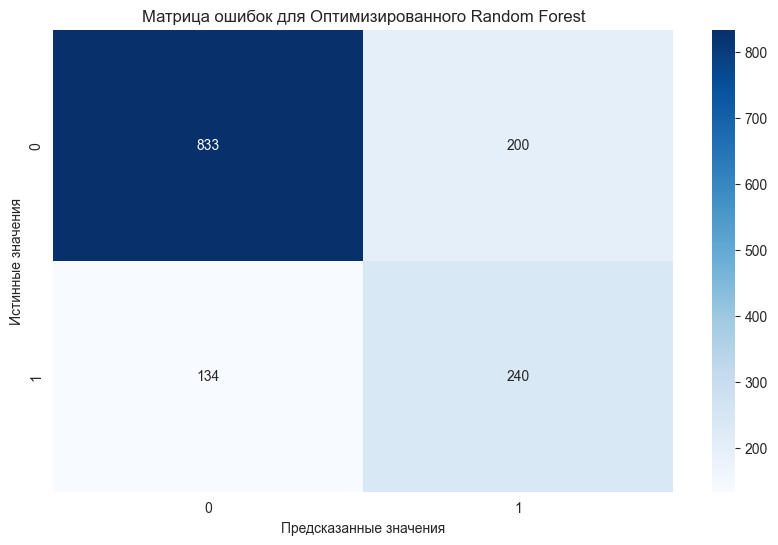


Отчет о классификации (Classification Report):
                precision    recall  f1-score   support

Оставшиеся (0)       0.86      0.81      0.83      1033
   Ушедшие (1)       0.55      0.64      0.59       374

      accuracy                           0.76      1407
     macro avg       0.70      0.72      0.71      1407
  weighted avg       0.78      0.76      0.77      1407

ROC-AUC Score: 0.7241


In [ ]:
# =============================================================================
# Шаг 3.1: Оптимизация и оценка Random Forest
# =============================================================================
from sklearn.model_selection import RandomizedSearchCV

print("--- 3.1. Оптимизация Random Forest ---")

# 1. Определение сетки гиперпараметров для перебора
param_grid_rf = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [10, 20, 30, None],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10]
}

# 2. Инициализация RandomizedSearchCV
# n_iter=50: количество комбинаций для проверки.
# cv=3: 3-кратная кросс-валидация для каждой комбинации.
# scoring='f1': цель - найти параметры, максимизирующие F1-score (баланс precision и recall).
# n_jobs=-1: использовать все доступные ядра процессора.
rf = RandomForestClassifier(random_state=42)
rf_random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_grid_rf,
                                      n_iter=50, cv=3, verbose=1, random_state=42,
                                      scoring='f1', n_jobs=-1)

# 3. Запуск поиска лучших параметров на сбалансированных данных
print("Запуск поиска лучших гиперпараметров для Random Forest...")
rf_random_search.fit(X_train_resampled, y_train_resampled)
print("Поиск завершен.")

# Выводим лучшие найденные параметры
print("\nЛучшие гиперпараметры:", rf_random_search.best_params_)

# 4. Получение лучшей модели
best_rf_model = rf_random_search.best_estimator_

# 5. Оценка лучшей модели на несбалансированной тестовой выборке
print("\n--- Оценка ОПТИМИЗИРОВАННОЙ модели Random Forest ---")
y_pred_rf_best = best_rf_model.predict(X_test)

# Матрица ошибок
print("Матрица ошибок (Confusion Matrix):")
cm_rf_best = confusion_matrix(y_test, y_pred_rf_best)
sns.heatmap(cm_rf_best, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок для Оптимизированного Random Forest')
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.show()

# Отчет о классификации
print("\nОтчет о классификации (Classification Report):")
print(classification_report(y_test, y_pred_rf_best, target_names=['Оставшиеся (0)', 'Ушедшие (1)']))

# ROC-AUC
roc_auc_rf_best = roc_auc_score(y_test, y_pred_rf_best)
print(f"ROC-AUC Score: {roc_auc_rf_best:.4f}")


--- 3.2. Оптимизация XGBoost ---
Запуск поиска лучших гиперпараметров для XGBoost...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


d:\portfolio\projects\churn_prediction_practice\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [18:17:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Поиск завершен.

Лучшие гиперпараметры: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05}

--- Оценка ОПТИМИЗИРОВАННОЙ модели XGBoost ---
Матрица ошибок (Confusion Matrix):


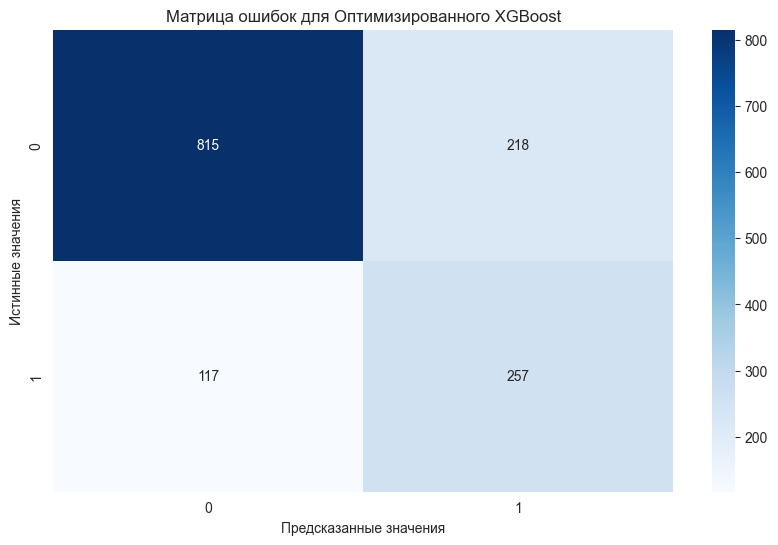


Отчет о классификации (Classification Report):
                precision    recall  f1-score   support

Оставшиеся (0)       0.87      0.79      0.83      1033
   Ушедшие (1)       0.54      0.69      0.61       374

      accuracy                           0.76      1407
     macro avg       0.71      0.74      0.72      1407
  weighted avg       0.79      0.76      0.77      1407

ROC-AUC Score: 0.7381


In [17]:
# =============================================================================
# Шаг 3.2: Оптимизация и оценка XGBoost
# =============================================================================
from sklearn.model_selection import RandomizedSearchCV

print("\n--- 3.2. Оптимизация XGBoost ---")

# 1. Определение сетки гиперпараметров для XGBoost
# learning_rate: скорость обучения
# subsample: доля строк для обучения каждого дерева
param_grid_xgb = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0]
}

# 2. Инициализация RandomizedSearchCV
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_random_search = RandomizedSearchCV(estimator=xgb, param_distributions=param_grid_xgb,
                                       n_iter=50, cv=3, verbose=1, random_state=42,
                                       scoring='f1', n_jobs=-1)

# 3. Запуск поиска на сбалансированных данных
print("Запуск поиска лучших гиперпараметров для XGBoost...")
xgb_random_search.fit(X_train_resampled, y_train_resampled)
print("Поиск завершен.")

# Выводим лучшие параметры
print("\nЛучшие гиперпараметры:", xgb_random_search.best_params_)

# 4. Получение лучшей модели
best_xgb_model = xgb_random_search.best_estimator_

# 5. Оценка лучшей модели на несбалансированной тестовой выборке
print("\n--- Оценка ОПТИМИЗИРОВАННОЙ модели XGBoost ---")
y_pred_xgb_best = best_xgb_model.predict(X_test)

# Матрица ошибок
print("Матрица ошибок (Confusion Matrix):")
cm_xgb_best = confusion_matrix(y_test, y_pred_xgb_best)
sns.heatmap(cm_xgb_best, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок для Оптимизированного XGBoost')
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.show()

# Отчет о классификации
print("\nОтчет о классификации (Classification Report):")
print(classification_report(y_test, y_pred_xgb_best, target_names=['Оставшиеся (0)', 'Ушедшие (1)']))

# ROC-AUC
roc_auc_xgb_best = roc_auc_score(y_test, y_pred_xgb_best)
print(f"ROC-AUC Score: {roc_auc_xgb_best:.4f}")


--- 3.3. Оптимизация LightGBM ---
Запуск поиска лучших гиперпараметров для LightGBM...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4130, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000677 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 819
[LightGBM] [Info] Number of data points in the train set: 8260, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

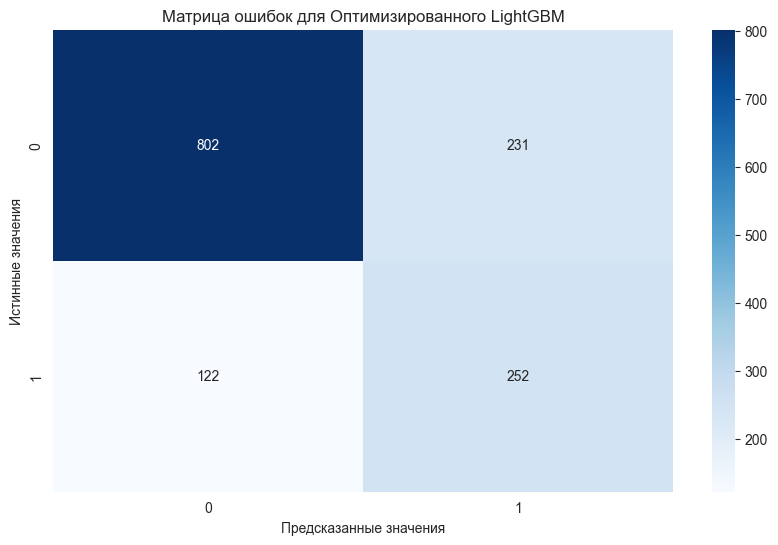


Отчет о классификации (Classification Report):
                precision    recall  f1-score   support

Оставшиеся (0)       0.87      0.78      0.82      1033
   Ушедшие (1)       0.52      0.67      0.59       374

      accuracy                           0.75      1407
     macro avg       0.69      0.73      0.70      1407
  weighted avg       0.78      0.75      0.76      1407

ROC-AUC Score: 0.7251


In [18]:
# =============================================================================
# Шаг 3.3: Оптимизация и оценка LightGBM
# =============================================================================
from sklearn.model_selection import RandomizedSearchCV

print("\n--- 3.3. Оптимизация LightGBM ---")

# 1. Определение сетки гиперпараметров для LightGBM
param_grid_lgbm = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 4, 5, 6, -1], # -1 означает без ограничения глубины
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 40, 50] # количество листьев в одном дереве
}

# 2. Инициализация RandomizedSearchCV
lgbm = LGBMClassifier(random_state=42)
lgbm_random_search = RandomizedSearchCV(estimator=lgbm, param_distributions=param_grid_lgbm,
                                        n_iter=50, cv=3, verbose=1, random_state=42,
                                        scoring='f1', n_jobs=-1)

# 3. Запуск поиска на сбалансированных данных
print("Запуск поиска лучших гиперпараметров для LightGBM...")
lgbm_random_search.fit(X_train_resampled, y_train_resampled)
print("Поиск завершен.")

# Выводим лучшие параметры
print("\nЛучшие гиперпараметры:", lgbm_random_search.best_params_)

# 4. Получение лучшей модели
best_lgbm_model = lgbm_random_search.best_estimator_

# 5. Оценка лучшей модели
print("\n--- Оценка ОПТИМИЗИРОВАННОЙ модели LightGBM ---")
y_pred_lgbm_best = best_lgbm_model.predict(X_test)

# Матрица ошибок
print("Матрица ошибок (Confusion Matrix):")
cm_lgbm_best = confusion_matrix(y_test, y_pred_lgbm_best)
sns.heatmap(cm_lgbm_best, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок для Оптимизированного LightGBM')
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.show()

# Отчет о классификации
print("\nОтчет о классификации (Classification Report):")
print(classification_report(y_test, y_pred_lgbm_best, target_names=['Оставшиеся (0)', 'Ушедшие (1)']))

# ROC-AUC
roc_auc_lgbm_best = roc_auc_score(y_test, y_pred_lgbm_best)
print(f"ROC-AUC Score: {roc_auc_lgbm_best:.4f}")


--- 3.4. Обучение и оценка ОПТИМИЗИРОВАННОГО Stacking Classifier ---
Обучение Stacking модели на оптимизированных базовых моделях...


d:\portfolio\projects\churn_prediction_practice\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [18:17:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4130, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000372 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 819
[LightGBM] [Info] Number of data points in the train set: 8260, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

d:\portfolio\projects\churn_prediction_practice\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [18:17:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\portfolio\projects\churn_prediction_practice\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [18:17:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\portfolio\projects\churn_prediction_practice\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [18:17:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\portfolio\projects\churn_prediction_practice\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [18:17:36] WARNING: C:\actions-r

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3304, number of negative: 3304
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000744 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 819
[LightGBM] [Info] Number of data points in the train set: 6608, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

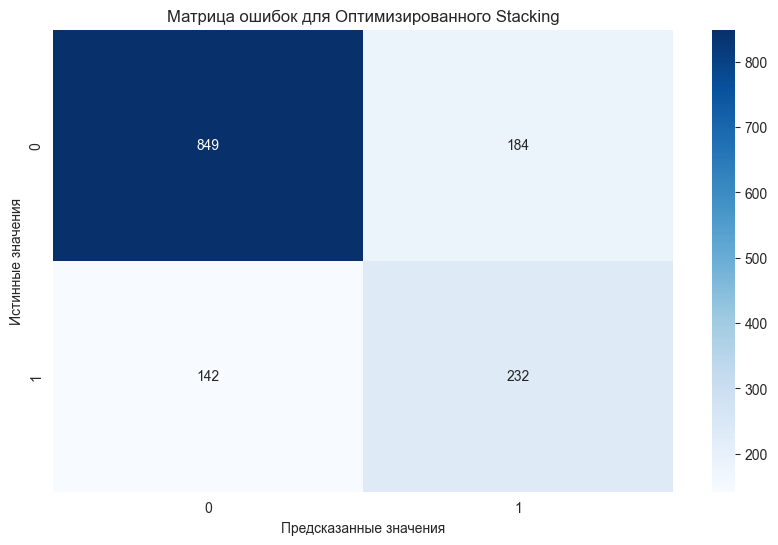


Отчет о классификации (Classification Report):
                precision    recall  f1-score   support

Оставшиеся (0)       0.86      0.82      0.84      1033
   Ушедшие (1)       0.56      0.62      0.59       374

      accuracy                           0.77      1407
     macro avg       0.71      0.72      0.71      1407
  weighted avg       0.78      0.77      0.77      1407

ROC-AUC Score: 0.7211


In [ ]:
# =============================================================================
# Шаг 3.4: Обучение и оценка Stacking
# =============================================================================

print("\n--- 3.4. Обучение и оценка Stacking Classifier ---")

# 1. Определяем базовые модели, используя наши лучшие найденные модели
estimators = [
    ('rf', best_rf_model),
    ('xgb', best_xgb_model),
    ('lgbm', best_lgbm_model)
]

# 2. Инициализация Stacking Classifier
final_estimator = LogisticRegression()
stacking_model_best = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=5
)

# 3. Обучение модели на сбалансированных данных
print("Обучение Stacking модели на оптимизированных базовых моделях...")
stacking_model_best.fit(X_train_resampled, y_train_resampled)
print("Модель обучена.")

# 4. Получение предсказаний
y_pred_stacking_best = stacking_model_best.predict(X_test)

# 5. Оценка модели
print("\n--- Оценка ОПТИМИЗИРОВАННОЙ модели Stacking ---")

# Матрица ошибок
print("Матрица ошибок (Confusion Matrix):")
cm_stacking_best = confusion_matrix(y_test, y_pred_stacking_best)
sns.heatmap(cm_stacking_best, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок для Оптимизированного Stacking')
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.show()

# Отчет о классификации
print("\nОтчет о классификации (Classification Report):")
print(classification_report(y_test, y_pred_stacking_best, target_names=['Оставшиеся (0)', 'Ушедшие (1)']))

# ROC-AUC
roc_auc_stacking_best = roc_auc_score(y_test, y_pred_stacking_best)
print(f"ROC-AUC Score: {roc_auc_stacking_best:.4f}")

--- Финальная таблица сравнения ОПТИМИЗИРОВАННЫХ моделей ---


,Model,Recall (Churn=1),F1-score (Churn=1),ROC-AUC
0,Optimized XGBoost,0.687166,0.605418,0.738065
1,Optimized LightGBM,0.673797,0.588098,0.725088
2,Optimized Random Forest,0.641711,0.589681,0.724050
3,Optimized Stacking,0.620321,0.587342,0.721099


C:\Users\Пользователь\AppData\Local\Temp\ipykernel_14660\2214430316.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Recall (Churn=1)', y='Model', data=comparison_df_best, palette='summer')


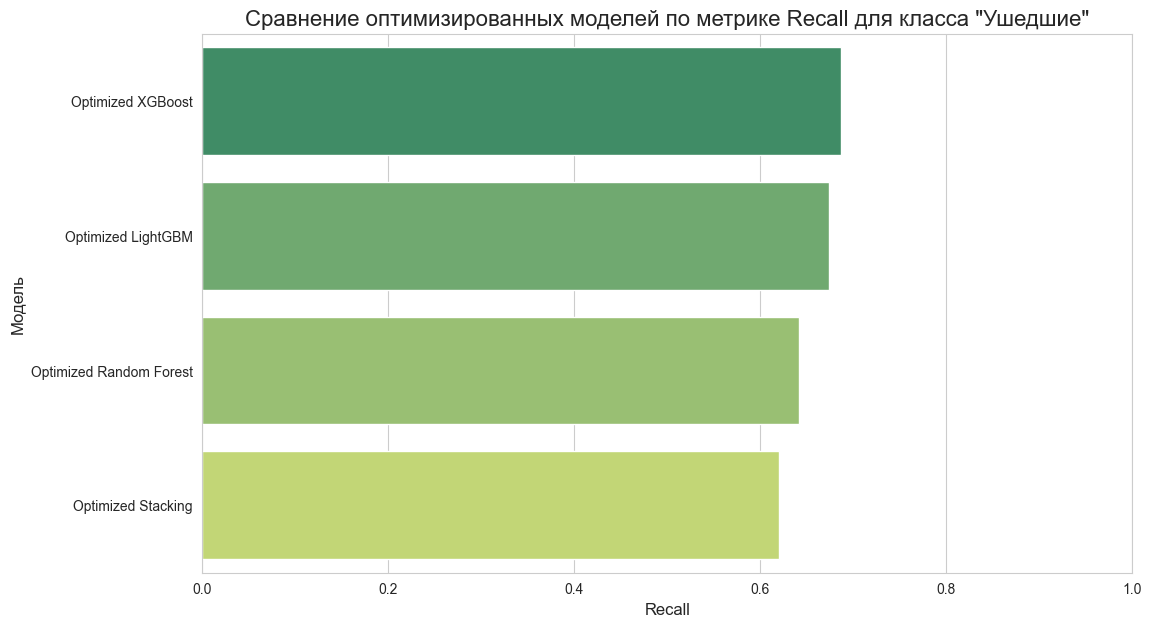

In [ ]:
# =============================================================================
# Шаг 4: Финальное сравнение оптимизированных моделей
# =============================================================================

# Собираем данные для таблицы
report_rf_best = classification_report(y_test, y_pred_rf_best, output_dict=True)
report_xgb_best = classification_report(y_test, y_pred_xgb_best, output_dict=True)
report_lgbm_best = classification_report(y_test, y_pred_lgbm_best, output_dict=True)
report_stacking_best = classification_report(y_test, y_pred_stacking_best, output_dict=True)

# Создаем DataFrame
comparison_data_best = {
    'Model': ['Optimized Random Forest', 'Optimized XGBoost', 'Optimized LightGBM', 'Optimized Stacking'],
    'Recall (Churn=1)': [
        report_rf_best['1']['recall'],
        report_xgb_best['1']['recall'],
        report_lgbm_best['1']['recall'],
        report_stacking_best['1']['recall']
    ],
    'F1-score (Churn=1)': [
        report_rf_best['1']['f1-score'],
        report_xgb_best['1']['f1-score'],
        report_lgbm_best['1']['f1-score'],
        report_stacking_best['1']['f1-score']
    ],
    'ROC-AUC': [roc_auc_rf_best, roc_auc_xgb_best, roc_auc_lgbm_best, roc_auc_stacking_best]
}

comparison_df_best = pd.DataFrame(comparison_data_best)
comparison_df_best = comparison_df_best.sort_values(by='Recall (Churn=1)', ascending=False).reset_index(drop=True)

print("--- Финальная таблица сравнения ОПТИМИЗИРОВАННЫХ моделей ---")
display(comparison_df_best)

# Визуализация сравнения
plt.figure(figsize=(12, 7))
sns.barplot(x='Recall (Churn=1)', y='Model', data=comparison_df_best, palette='summer')
plt.title('Сравнение оптимизированных моделей по метрике Recall для класса "Ушедшие"', fontsize=16)
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Модель', fontsize=12)
plt.xlim(0, 1.0)
plt.show()

--- 5.1 Сравнение важности признаков ---


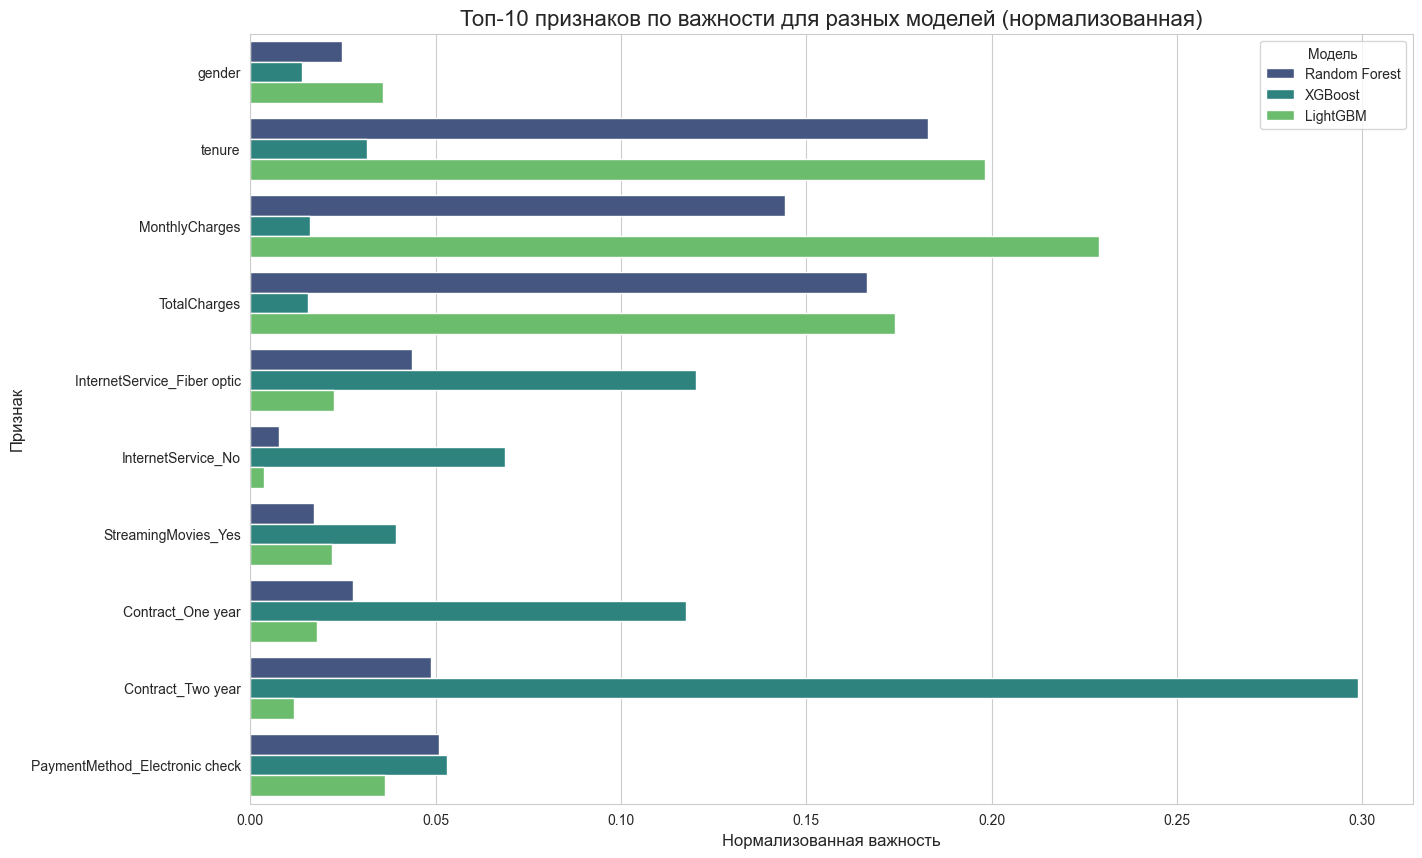

In [ ]:
# =============================================================================
# Шаг 5.1: Сравнение общей важности признаков
# =============================================================================

print("--- 5.1 Сравнение важности признаков ---")

models = [
    ('Random Forest', best_rf_model),
    ('XGBoost', best_xgb_model),
    ('LightGBM', best_lgbm_model)
]

feature_importance_df = pd.DataFrame()

for name, model in models:
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        
        # --- НАЧАЛО ИСПРАВЛЕНИЯ ---
        # Нормализуем значения важности, чтобы они были в одном масштабе
        normalized_importances = importances / np.sum(importances)
        # --- КОНЕЦ ИСПРАВЛЕНИЯ ---
        
        temp_df = pd.DataFrame({
            'Feature': X_train.columns,
            'Importance': normalized_importances, # Используем нормализованные значения
            'Model': name
        })
        feature_importance_df = pd.concat([feature_importance_df, temp_df])

# Дальнейший код остается без изменений
top_features = feature_importance_df.groupby('Feature')['Importance'].mean().sort_values(ascending=False).head(10).index
plot_df = feature_importance_df[feature_importance_df['Feature'].isin(top_features)]

plt.figure(figsize=(15, 10))
sns.barplot(x='Importance', y='Feature', hue='Model', data=plot_df, palette='viridis')
plt.title('Топ-10 признаков по важности для разных моделей (нормализованная)', fontsize=16)
plt.xlabel('Нормализованная важность', fontsize=12)
plt.ylabel('Признак', fontsize=12)
plt.legend(title='Модель')
plt.show()


--- 5.2 Глубокий SHAP-анализ для Optimized LightGBM ---


d:\portfolio\projects\churn_prediction_practice\.venv\Lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(



Детальное влияние признаков на предсказание оттока (SHAP Summary Plot)


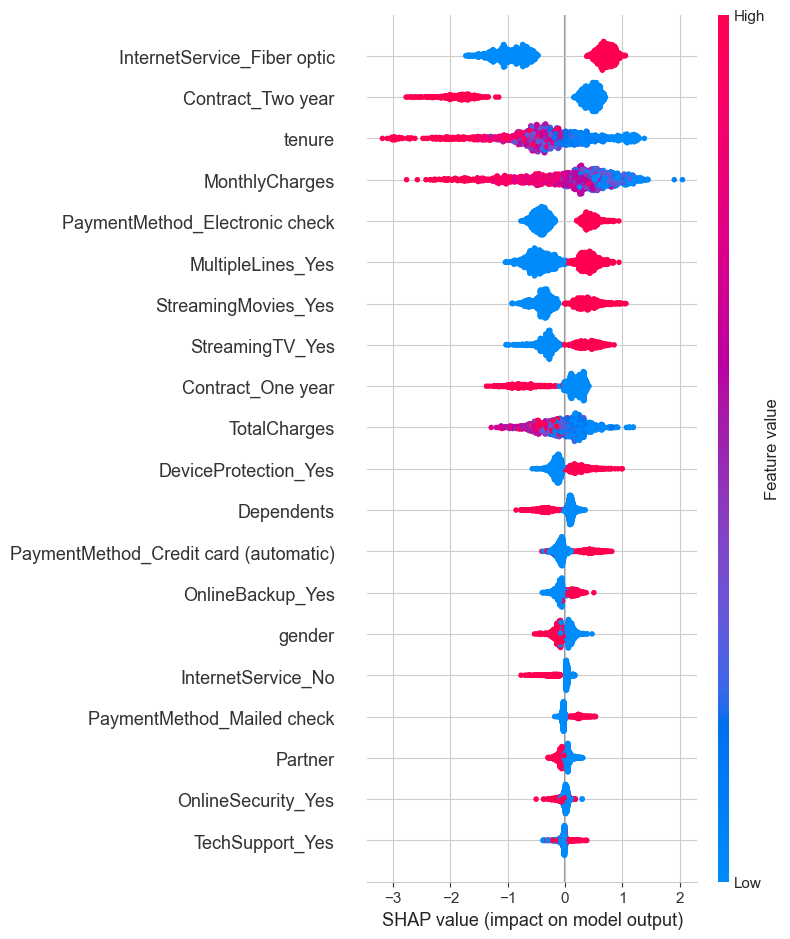

In [ ]:
# Попытка провести SHAP-анализ лучшей из полученных моделей - XGBoost, приводит к ошибке из-за несоответствия типов переменных внутри модели и функций модуля SHAP.
# Из-за неудачи при попытках преодоления этой ошибки было принято решение использовать модель занявшую второе место - LightGBM
#
# =============================================================================
# Шаг 5.2: Глубокий SHAP-анализ лучшей модели
# =============================================================================
import shap

print("\n--- 5.2 Глубокий SHAP-анализ для Optimized LightGBM ---")

explainer_lgbm = shap.TreeExplainer(best_lgbm_model)
shap_values_lgbm = explainer_lgbm.shap_values(X_test)

# Визуализация: Влияние значений признаков (Beeswarm Plot)
print("\nДетальное влияние признаков на предсказание оттока (SHAP Summary Plot)")

# --- НАЧАЛО ИСПРАВЛЕНИЯ ---
# Убираем индексацию [1]. shap_values_lgbm уже содержит нужный массив для класса 1.
# Проверяем размерность на всякий случай, чтобы понять, что происходит
if isinstance(shap_values_lgbm, list):
    # Если это список (для классов 0 и 1), берем значения для класса 1
    shap.summary_plot(shap_values_lgbm[1], X_test)
else:
    # Если это один массив (только для класса 1), используем его напрямую
    shap.summary_plot(shap_values_lgbm, X_test)
# --- КОНЕЦ ИСПРАВЛЕНИЯ ---